# Secondary Tilt Factors

Screen tilt distance against eddy structure, stratification, and propagation diagnostics.


In [1]:
import matplotlib.pyplot as plt

import seacofs_tilt_tools as tilt

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df_eddies, df_tilt = tilt.load_tilt_tables(paths)
dic_vert = tilt.load_vertical_dictionary(paths)
df_eddies = tilt.add_top_bottom_speeds(df_eddies, dic_vert)

In [4]:
# Nbar
df_eddies = tilt.compute_core_mean(
    df_eddies,
    grid,
    base_path="/srv/scratch/z5297792/Climatology/N2s/Nbars_300m_depth",
    varname="Nbar",
    colname="Nbar"
)

In [5]:
df_eddies[["Eddy", "Day", "Cyc", "TiltDis", "Omega", "AR", "Nbar", "EddyProp", "btm_prop"]].head()

,Eddy,Day,Cyc,TiltDis,Omega,AR,Nbar,EddyProp,btm_prop
0,1,1462,CE,NaN,-0.000007,1.434563,NaN,NaN,NaN
1,1,1463,CE,NaN,-0.000006,1.417135,NaN,0.104026,0.127027
2,1,1464,CE,NaN,-0.000006,1.413542,NaN,0.104026,0.075304
3,1,1465,CE,33.976810,-0.000009,1.411879,0.010134,0.189457,0.020750
4,1,1466,CE,30.067059,-0.000009,1.597888,0.010182,0.039522,0.054524


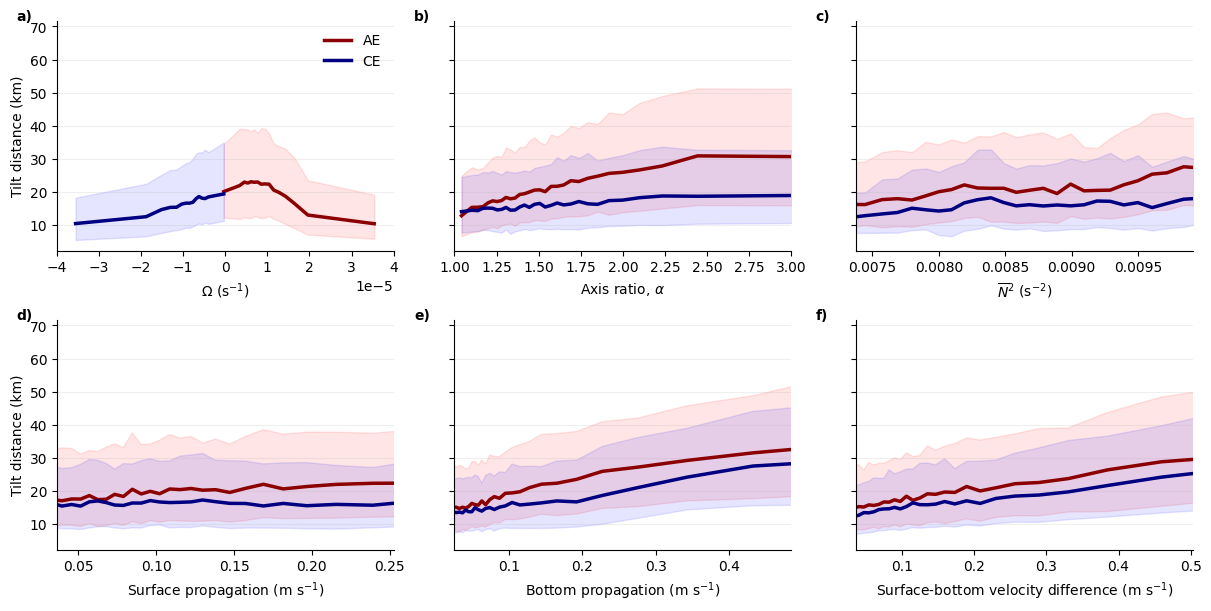

In [6]:
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharey=True, constrained_layout=True)
axs = axs.ravel()

panels = [
    ("Omega", r"$\Omega$ (s$^{-1}$)", (-4e-5, 4e-5)),
    ("AR", r"Axis ratio, $\alpha$", (1, 3)),
    ("Nbar", r"$\overline{N}^2$ (s$^{-2}$)", None),
    ("EddyProp", "Surface propagation (m s$^{-1}$)", None),
    ("btm_prop", "Bottom propagation (m s$^{-1}$)", None),
    ("top_btm_diff", "Surface-bottom velocity difference (m s$^{-1}$)", None),
]

for label, ax, (col, xlabel, xlim) in zip("abcdef", axs, panels):
    tilt.binned_tilt_panel(ax, df_eddies, col, xlabel, ylabel="Tilt distance (km)" if label in "ad" else None, xlim=xlim)
    ax.text(-0.12, 1.05, f"{label})", transform=ax.transAxes, fontweight="bold", va="top")
axs[0].legend(frameon=False)
plt.show()


In [7]:
summary = (
    df_eddies
    .groupby("Cyc")[["TiltDis", "Omega", "AR", "Nbar", "EddyProp", "btm_prop", "top_btm_diff"]]
    .agg(["count", "median", "mean"])
)
summary


TiltDis                        Omega                         AR            \
      count     median       mean  count    median      mean  count    median   
Cyc                                                                             
AE    53193  19.577262  26.125517  63831  0.000009  0.000011  63831  1.438583   
CE    51266  16.036396  21.559841  61395 -0.000009 -0.000010  61395  1.549044   

                Nbar  ...           EddyProp                     btm_prop  \
         mean  count  ...      mean    count    median      mean    count   
Cyc                   ...                                                   
AE   1.532789  53193  ...  0.008408    62417  0.103251  0.128446    62417   
CE   1.648219  51266  ...  0.008906    59880  0.107398  0.131680    59880   

                        top_btm_diff                      
       median      mean        count    median      mean  
Cyc                                                       
AE   0.085922  0.191645        62417  0.138961  0.229014  
CE   0.079766  0.167954        59880  0.120597  0.199531  

[2 rows x 21 columns]

In [9]:
rho0 = 1025
df_eddies['Q'] = df_eddies.Nbar * (grid.f[df_eddies.ic, df_eddies.jc] + df_eddies.w) / rho0

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), sharey=True, constrained_layout=True)
tilt.binned_tilt_panel(ax, df_eddies, 'Q', xlabel, ylabel="Tilt distance (km)")


<Axes: xlabel='Surface-bottom velocity difference (m s$^{-1}$)', ylabel='Tilt distance (km)'>